# Lab 1: The Apollo Missions

## Introduction
------

Imagine you are an engineer working on the very early days of the Apollo program. In order to
send people to the moon, you need a basic understanding of the gravitational potential and forces
the mission will experience. You also need to start quantifying the performance of the new rocket
that will carry the capsule: the Saturn V.

Your team at NASA has been tasked with conducting a series of investigations, which you are guided through below.
You will make some plots, and also write some short paragraphs with your scientific conclusions.
The NASA Director Gene Kranz will use your notebook to defend NASA funding to congress.
So your answers should be short and to the point, quantitative in nature, 
and contain highly polished plots, with appropriate titles, units, etc.

**Other important requirements:**
- Your final notebook---BOTH the .ipynb file AND the html export---should be COMMITTED and PUSHED to your fork of the PHYS265-spring26 GitHub repository. Instructions for doing this are available [online]( https://github.com/astroumd/PHYS265-spring26/blob/main/github.pdf).
- All plotting should be done in object oriented fashion, as discussed in class. 
Any use of “`plt.plot()`” will result in zero points being awarded for that question.
- Before submitting your work, reset JLD and then re-run your final code (Kernel → Restart Kernel and Run All Cells…) Make sure your code executes as intended and without error. The first cell should be "1", and the cells should execute in order.

A table of relevant physical constants is below. Good luck!

| Quantity | Value |
|----------|-------|
| Gravitational Constant ($G$) | $6.67 \times 10^{-11}$ m³/kg/s² |
| Gravitational Acceleration ($g$) | 9.81 m/s² |
| Mass of the Earth ($M_E$) | $5.9 \times 10^{24}$ kg |
| Mass of the Moon ($M_M$) | $7.3 \times 10^{22}$ kg |
| Mass of Apollo Command Module | 5500 kg |
| Radius of the Earth ($R_E$) | 6378 km |
| Radius of the Moon ($R_M$) | 1737 km |
| Distance from Earth to Moon ($d_{EM}$) | $3.8 \times 10^{8}$ m |
| Exhaust Velocity of Saturn V Stage 1 (S-1C) ($v_e$) | $2.4 \times 10^{3}$ m/s |
| Burn Rate of S-1C ($\dot{m}$) | $1.3 \times 10^{4}$ kg/s |
| Wet Mass of S-1C ($m_0$) | $2.8 \times 10^{6}$ kg |
| Dry Mass of S-1C ($m_f$) | $7.5 \times 10^5$ kg |

In [1]:
#show
# In the code cell beneath this one you can put your imports,
# and define any variables you might need (e.g. the mass of the earth)

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math
G= 6.67*(10**(-11))
dEM=3.8*(10**8)
ME=5.9*(10**24)
MM=7.3*(10**22)

MAM=5500.0

g=9.81
mo=2.8*(10**6)
mf=7.5*(10**5)
mdot=1.3*(10**4)
ve=2.4*(10**3)

## Part 1: The Gravitational Potential of the Earth
----

The gravitational potential at a distance $r$ from a mass $M$ is given by:

$$\Phi(r) = -\frac{GM}{r}$$

where G is the gravitational constant.

1. Code up a function that takes as an input the mass of a body $M$ , the cartesian location of the
mass $(x_M , y_M)$, and the location of some distant evaluation point $(x, y)$. Have the function
return the potential at the evaluation point. You may consider approximating the Earth as
a point particle, but in which case, be careful! For in that approximation, the the potential
contains a singularity. In our function, use all modern best practices for coding.
E.g. type hints, type checks, pre and post conditions, doc strings, etc.

In [3]:
def GravU_doc(M,xM,yM,xe,ye):
    """ An equation which gives you the gravitational potential energy at a point a distance away from a body of a certain mass.

     Args:
     M : Mass of body
     xM : X coordinate of the mass M
     yM : Y coordinate of the mass M
     xe : X coordinate of the point of evaluation
     ye : Y coordinate of the point of evaluation

     Returns:
     The gravitational potential energy at a point away from a mass.
     """
def GravU(M : float, xM : float, yM: float, xe: float, ye: float) -> float:
    if not isinstance(M, float):
        raise TypeError(f" Input is the wrong type :o")
    if not isinstance(xM, float):
        raise TypeError(f" Input is the wrong type :o")
    if not isinstance(yM, float):
        raise TypeError(f" Input is the wrong type :o")
   # if not isinstance(xe, float):
   #     raise TypeError(f" Input is the wrong type :o")
   # if not isinstance(ye, float):
   #     raise TypeError(f" Input is the wrong type :o")
    if M < 0:
        raise ValueError(f" M value cannot be negative :o")
    den= (np.sqrt((xe-xM)**2+(ye-yM)**2))
  #  if np.isclose(den,0):
 #       return np.nan
    den=np.where(np.isclose(den,0),np.nan,den)
    GravPotential = -(G*M)/(den)
   # assert isinstance(GravPotential, float), "The gravitational potential is not a float..."
   # assert np.all(GravPotential) < 0, "The computed gravitational potential is not =<0 ..."
    assert np.any(np.isfinite(GravPotential)), "Gravitational Potential has to be finite 7-7"
    return -(G*M)/(den)

2. Make a 1D plot of the absolute value of the gravitational potential $|\Phi|$ as a function of distance $x$ from the surface of the Earth, assuming $y = 0$.
Plot out to $1.5\times$ the distance from the Earth to the Moon. Because the potential falls quickly with r, make the y-axis logarithmic to visualize it better.

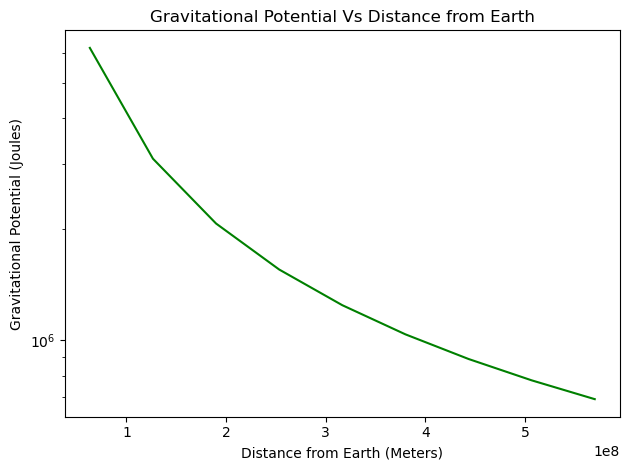

In [4]:
fig, ax1=plt.subplots()

d1=(1.5*dEM)
x1 =np.linspace(0.0,d1, 10)
y1 = GravU(ME,0.0,0.0,x1,0.0)

ax1.plot(x1,np.abs(y1), "green")
ax1.set_title("Gravitational Potential Vs Distance from Earth")
ax1.set_ylabel("Gravitational Potential (Joules)")
ax1.set_xlabel("Distance from Earth (Meters)")
ax1.set_yscale("log")
fig.tight_layout()

3. Then, make a 2D color-mesh plot of the potential $\Phi$ with the Earth at the origin. Plot $|\Phi|$
over a large range of $x$ and $y$, for example, from $-1.5d_{EM}$ to $+1.5d_{EM}$ . Force the plot to have
a square aspect ratio. Make sure to add a nice colorbar, and make the colorbar logarithmic.

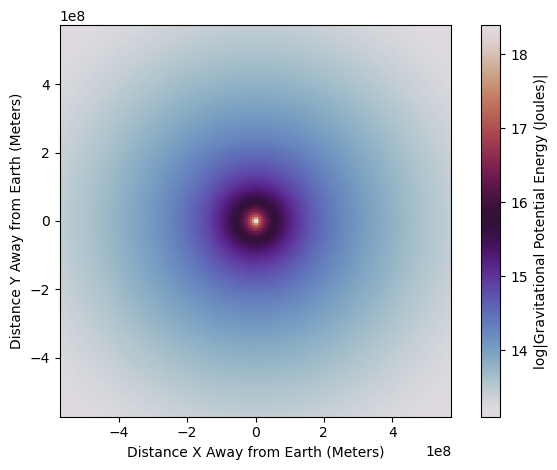

In [5]:
x2=np.linspace(-(1.5*dEM),(1.5*dEM),200)
y2=np.linspace(-(1.5*dEM),(1.5*dEM),200)

x_grid2, y_grid2 = np.meshgrid(x2,y2)

z2 = GravU(ME,0.0,0.0,x_grid2,y_grid2)

fig, ax2= plt.subplots()
ax2.set_aspect("equal")
ax2.set_xlabel("Distance X Away from Earth (Meters)")
ax2.set_ylabel("Distance Y Away from Earth (Meters)")

z2log=np.log(abs(z2))
mesh = ax2.pcolormesh(x_grid2, y_grid2,z2log, cmap='twilight')

cbar= fig.colorbar(mesh)
cbar.set_label("log|Gravitational Potential Energy (Joules)|")

fig.tight_layout()
ax2.set_aspect("equal")

## Part 2: The Gravitational Potential of the Earth-Moon System
-----

Now, imagine the Earth is at the origin $(x_{E},y_{E}) = (0,0)$, 
and the moon is at a location $(x_{M},y_{M}) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$.

1. Make an updated 2D color-mesh plot, from $-1.5d_{EM}$ to $+1.5d_{EM}$,
of the gravitational potential of the combined Earth-Moon system.

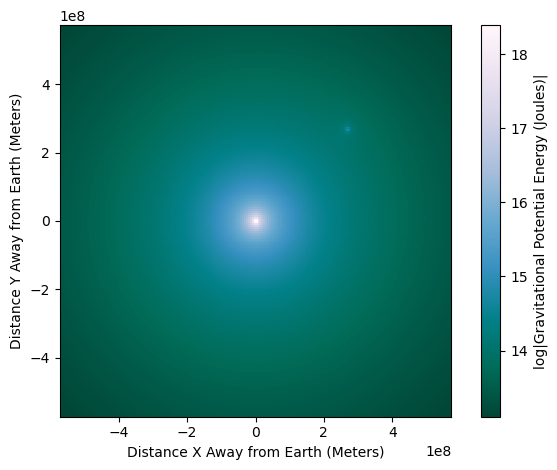

In [6]:
x3=np.linspace(-(1.5*dEM),(1.5*dEM),200)
y3=np.linspace(-(1.5*dEM),(1.5*dEM),200)

x_grid3, y_grid3 = np.meshgrid(x3,y3)

z3 = GravU(ME,0.0,0.0,x_grid3,y_grid3)
d2= (dEM/(np.sqrt(2)))
z4 = GravU(MM,d2,d2,x_grid3,y_grid3)
ztotal=z3+z4
ztotallog=np.log(abs(ztotal))


fig, ax3= plt.subplots()
mesh1 = ax3.pcolormesh(x_grid3, y_grid3,ztotallog, cmap='PuBuGn_r')
ax3.set_aspect("equal")
ax3.set_xlabel("Distance X Away from Earth (Meters)")
ax3.set_ylabel("Distance Y Away from Earth (Meters)")

cbar= fig.colorbar(mesh1)
cbar.set_label("log|Gravitational Potential Energy (Joules)|")
fig.tight_layout()

2. Additionally, make a 2D contour plot over the same $x$ and $y$ range.
Do not let all the contours bunch up around the Earth and Moon.
You will probably again need to tell matplotlib to use a logarithmic color scale.

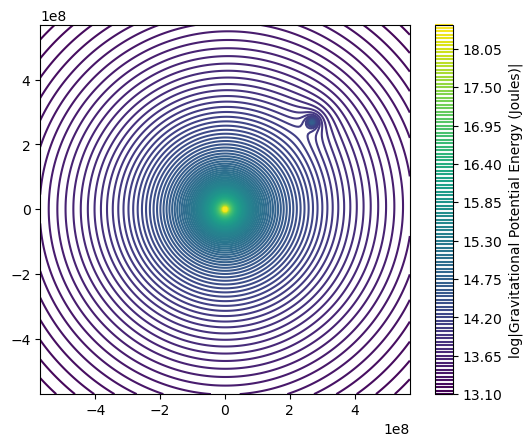

In [7]:
fig, ax4=plt.subplots()
contour3=ax4.contour(x_grid3,y_grid3,ztotallog,cmap="viridis",levels=120)

ax4.set_aspect("equal")
cbar = fig.colorbar(contour3)
# cbar.set_scale("log")
cbar.set_label("log|Gravitational Potential Energy (Joules)|")

## Part 3: The Gravitational Force Field of the Earth-Moon System
----
The gravitational force $\vec{F}$ 
that a mass $M_1$ exerts on a mass $m_2$ is:

$$\vec{F}_{21} = -G \frac{M_1 m_2}{|\vec{r}_{21}|^2} \hat{r}_{21}$$

where $\vec{r}_{21}$ is the displacement vector from $M_1$ to $m_2$.

1. Code up a function that takes as an input the mass of a body $M_1$, 
the mass of a secondary body $m_2$,
the cartesian location of the first mass $(x_1, y_1)$, 
and the cartesian location of the second body $(x_2, y_2)$. 
Have the function return the two gravitational force components, 
$F_x$ and $F_y$, experienced by the mass $m_2$ 
from the force exerted by $M_1$.
Note that the gravitational force contains a singularity, 
and so if you made the approximation that the Earth is a finite point,
you will need to avoid it.
Like for the 1D potential, make sure it follows modern best-coding practices.

In [8]:
def ForceG_doc(M1,m2,x11,y11,x12,y12):
    """A function which calculates the force one body of mass M1 exerts on another of mass m2.

    Args:
        M1 (float): Mass of first body
        m2 (float): Mass of second body
        x11 : X cooordinate of M1
        y11 : Y coordinate of M1
        x12 : X coordinate of m2
        y12 : Y coordinate of m2

    Returns:
        Forces "Fx" and "Fy" exerted by M1 onto m2 along their respective axis
    """
def ForceG(M1 : float,m2 : float,x11 : float,y11 : float,x12 : float,y12: float)->float:
    if not isinstance(M1, float):
        raise TypeError(f" Input is the wrong type :o")
    if not isinstance(m2, float):
        raise TypeError(f" Input is the wrong type :o")
    if M1 < 0:
        raise ValueError(f" M1 value cannot be negative :o")
    if m2 < 0:
        raise ValueError(f"m2 value cannot be negative :|")
    dx1=x11-x12
    dy1=y11-y12
    r21=np.sqrt(dx1**2 +dy1**2)
    r21=np.where(np.isclose(r21,0),np.nan,r21)
  #  GForce = (-(G*M1*m2)/(den1**2))
  #  Theta=(np.arctan((y11-y12)/(x11-x12)))
    GFx = -(G*M1*m2)*(dx1/(r21**3))
    GFy = -(G*M1*m2)*(dy1/(r21**3))
   # assert isinstance(GravForce, float), "The gravitational force is not a float..."
    assert np.any(np.isfinite(GFx)), "Gravitational force cannot be infinite"
    return GFx, GFy

2. Assuming the Earth is still at the origin and the Moon is still at 
$(x_M, y_M) = \big( \frac{d_{EM}}{\sqrt{2}}, \frac{d_{EM}}{\sqrt{2}} \big)$, 
make a 2D streamplot of the gravitational force the Earth-Moon system 
will exert on the Apollo 11 command module.
Plot the force over the same x-y range of $-1.5 d_{EM}$ to $+1.5 d_{EM}$.
Add a nice color bar, which will again probably need to be logarithmic.
Mark the location of the earth with a black circle, and the moon with a black square.
Add a legend.

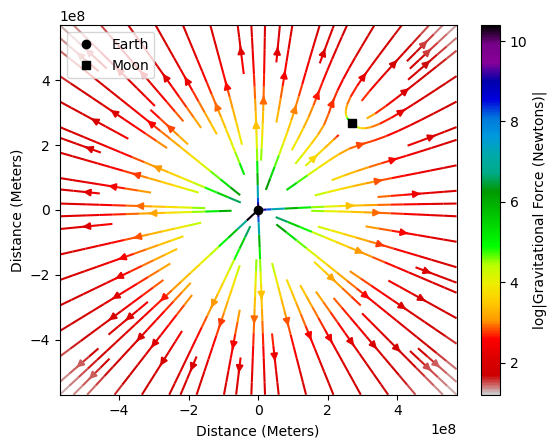

In [9]:
fig, ax5=plt.subplots()

x5=np.linspace(-1.5*dEM,1.5*dEM,100)
y5=np.linspace(-1.5*dEM,1.5*dEM,100)
xgrid5,ygrid5 = np.meshgrid(x5,y5)
FEx,FEy = ForceG(ME,MAM,0,0,xgrid5,ygrid5)
FMx,FMy = ForceG(MM,MAM,d2,d2,xgrid5,ygrid5)
Totx=FEx+FMx
Toty=FEy+FMy
TotZ=np.sqrt(Totx**2 + Toty**2)
logTot=np.log(abs(TotZ))

strm5=ax5.streamplot(xgrid5,ygrid5,Totx,Toty,color=logTot,cmap='nipy_spectral_r')

ax5.plot(0,0,"o",color="black",label="Earth")
ax5.plot(d2,d2,"s",color="black",label="Moon")
ax5.legend(loc="upper left")
    
ax5.set_ylabel("Distance (Meters)")
ax5.set_xlabel("Distance (Meters)")
cbar5=fig.colorbar(strm5.lines)
cbar5.set_label("log|Gravitational Force (Newtons)|")


3. You will note there is a point between the Earth and the Moon where the field lines seem to vanish. This is the point where the Earth's and Moon's gravitational forces cancel eachother. By setting $|\vec{F}_{moon}| = |\vec{F}_{earth}|$, calculate the radial distance of the "balance point." From there, identify the $x$ and $y$ coordinates of the balance point. Typeset your derivation (show multiple steps!) in latex in a markdown cell below. Then, calculate it numerically, and draw the answer onto a new version of your force field plot. Again mark the location of the earth with a black circle, and the moon with a black square; mark the location of the balance point with a red x. Add a legend.

**Your Derivation Goes in the markdown cell below:**

1.)
General Equation
$$
F= \frac{GMm}{r^2}
$$
Earth & Apollo craft
$$
F_E=\frac{GM_Em}{r_E^2}
$$
Moon & Apollo craft
$$
F_M=\frac{GM_Mm}{r_M^2}
$$
2.)
Set equal
$$
\frac{GM_Em}{r_E^2} = \frac{GM_Mm}{r_M^2}
$$
3.)
See that things cancel (the G and m)
$$
\frac{M_E}{r_E^2}=\frac{M_M}{r_M^2}
$$
4.)
Substitute values in for $r_E$ and $r_M$
$$r_{EA}=$$ Distance from Earth to Apollo craft
$$d_{EM}=$$Distance between Earth and Moon
$$\frac{M_E}{r_{EA}^2} = \frac{M_M}{(d_{EM}-r_{EA})^2}$$
5.)
Solve for r now...
I square rooted both sides and then got the $r_{EA}$ in the numerators. Then I distributed the $M_E$ and eventually got $r_{EA}$ by itself:
$$r_{EA}=\frac{\sqrt{M_E}d_{EM}}{(\sqrt{M_M}+\sqrt{M_E}}$$
6.)
Now I can sub in the values we already know

And your updated plot, including the balance point, goes in the cell below.

r_EA=341962346.91181517 meters from Earth


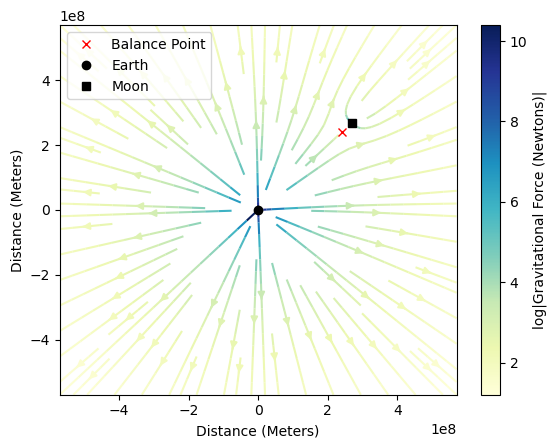

In [10]:
r_EA=(np.sqrt(ME)*(dEM))/(np.sqrt(MM)+np.sqrt(ME))
print(f"r_EA={r_EA} meters from Earth")

fig, ax6=plt.subplots()
strm6=ax6.streamplot(xgrid5,ygrid5,Totx,Toty,color=logTot,cmap='YlGnBu')

bx=r_EA/(np.sqrt(2))
by=r_EA/(np.sqrt(2))

ax6.plot(bx,by,"x",color="red",label="Balance Point")
ax6.plot(0,0,"o",color="black",label="Earth")
ax6.plot(d2,d2,"s",color="black",label="Moon")
ax6.legend(loc="upper left")
    
ax6.set_ylabel("Distance (Meters)")
ax6.set_xlabel("Distance (Meters)")
cbar6=fig.colorbar(strm6.lines)
cbar6.set_label("log|Gravitational Force (Newtons)|")

4. Quantitatively discuss your conclusions. Is the balance point close to the Moon or Earth? How close? Does this make sense?

**Your Answer Goes in the markdown cell below:**

The balance point is much closer to the moon than the earth, basically right outside of it on the graph. This makes sense that it would be further away from the Earth because the Earth has a much bigger mass than the Moon that it greatly overpowers its gravitational force. So, the point where it balances out would have to be much closer to the moon because the closer to the moon, the stronger its gravitational force gets.

## Part 4: Altitude of the Saturn V Rocket
----
Rockets function by conservation of momentum.
The ejection of fuel backwards propels the rocket forwards.
The change in a rocket's velocity $\Delta v$ as a 
function of time $t$ (under a set of simplifying assumptions) 
is given by the Tsiolkovsky rocket equation:

$$\Delta v(t) = v_e \ln \left(\frac{m_0}{m(t)}\right) - gt$$

where $m_0$ is the initial "wet" mass (fuel + rocket parts + payload), 
$m(t) = m_0 - \dot{m}t$ is the mass at time $t$, 
$\dot{m}$ is the fuel burn rate (which we will assume to be constant), 
$v_e$ is the fuel exhaust velocity, and $g$ is the gravitational acceleration.

You can find the altitude $h$ of the rocket at "burnout" 
(when all the fuel is used up) by integrating the velocity over time:

$$h = \int_{0}^{T} \Delta v(t) \, dt$$

where $T$ is the total burn time of the rocket, 
which by conservation of momentum arguments is:

$$T = \frac{m_0 - m_f}{\dot{m}}$$

where $m_f$ is the final "dry mass" of the rocket, 
once all the fuel is burned.

1. Calculate the burn time $T$ for the first stage of
the new Saturn V rocket that NASA is planning
to use to carry the Apollo capsule.

In [11]:
T=(mo-mf)/(mdot)
print(f"T={T} seconds")

T=157.69230769230768 seconds


2. Define a function that returns the change in velocity $\Delta v(t)$.
It should take all necessary arguments, meaning: the time, 
wet mass, dry mass, burn rate, exhaust speed, and gravitational constant $g$. 
Have it return the change in velocity.
Note that the rocket eventually runs out of fuel, 
so you should design your function carefully so that 
$\Delta v$ eventually becomes zero after all fuel is spent.
Again, document and guard your function according to best practices.

In [12]:
def vChange_doc(t1,mo1,mf1,mdot1,ve1,g1):
 """A function which calculates the change in velocity of a rocket.

    Args:
        t1 : Time
        mo1 (float): Wet mass
        mf1 (float): Dry mass
        mdot1 (float): Burn rate of fuel
        ve1 (float): Exhaust speed
        g1 (float): Gravitational constant

    Returns:
        Change in velocity of rocket.
    """
def vChange(t1,mo1,mf1,mdot1,ve1,g1):
    if not isinstance(mo1, float):
        raise TypeError(f" Input is the wrong type :o")
    if not isinstance(mf1, float):
        raise TypeError(f" Input is the wrong type :o")
    if t1 < 0:
        raise ValueError(f" Time (t1) value cannot be negative :o")
    if mo1 < 0:
        raise ValueError(f" Wet mass (mo1) value cannot be negative :|")
    if mf1 < 0:
        raise ValueError(f" Dry mass (mf1) value cannot be negative :|")
    if g1 < 0:
        raise ValueError(f" Gravitational constant (g1) value cannot be negative :|")
    if mo1<mf1:
        raise ValueError(f" Wet mass (mo1) cannot be less than the dry mass (fm1)")
    if mdot1<0:
        raise ValueError(f" Burn rate (mdot1) cannot be negative")
    T1 = (mo1-mf1)/(mdot1)
    T1 = np.where(np.isclose(T1,0),np.nan,T1)
    if t1 > T1:
        return 0
    inside=mo1/(mo1-mdot1*(t1))
    deninside=mo1-mdot1*(t1)
    inside=np.where(np.isclose(inside,0),np.nan,inside)
    deninside=np.where(np.isclose(deninside,0),np.nan,deninside)
    deltav = ((ve1)*(np.log(inside)))-(g1)*(t1)
    assert np.isfinite(deltav), "Velocity has to be finite!"
    return deltav

3. Compute the altitude of the rocket at the end of the burn.
Do this by numerically integrating from $t=0$ (launch) to $t=T$ (burnout).
Use the `scipy.integrate.quad()` function.

In [13]:
from scipy.integrate import quad
vt= lambda t1: vChange(t1,mo,mf,mdot,ve,g)
h= quad(vt,0,T)
print(f"Altitude of rocket at the end of the burn = {h}")

Altitude of rocket at the end of the burn = (74093.98013366401, 5.848811185394151e-08)


4. Just last week, NASA got the test results back from the first prototype
of Saturn V. They found that it burned for about 160 seconds
and lifted the system to an altitude of about 70km.
Director Kranz has asked you to compare your calculations for 
$T$ and $h$ to the testing data.
You should offer some explanations about why your calculation
is an over or under estimate, e.g. neglecting drag.

**Your Answer Goes in the markdown cell below:**

According to my calculations, I got that the rocket would reach an altitude of around 74,094 meters at the end of its burn. This is noticeably higher than the actual recorded altitude of 70,000 meters. My equations I used were for optimal conditions, like no air resistance, perfect weather, no wind, etc. So, it would make sense that my prediction was higher than what actually happened because in real life, it is not perfect so things will not go as smoothly as they would in a vaccum (so a lower height reached).

Additionally, my T value I calculated was around 157.69 seconds. This is lower than what actually was recorded (160 seconds). This could be because of many different reasons but one of the most likely is that the burn rate is not actually constant. For my equation, I assumed it was constant, however, in real life, it probably varies. So, a possible explanation as to why my calculation underestimated the burn time is because the burn rate actually slowed down at times or burned slower than expected, and slower than the constant number I used for it.